In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow import keras
from torchvision import transforms
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

## CNN Model Creation
The following function builds the basic CNN model that will be used as a "benchmark" model to compare how data impacts the results of the prediction model. The model consists of three convolutional layers, each followed by max-pooling to downsample features.
A fully connected dense layer helps learn patterns before the final classification layer.
The softmax output layer assigns probabilities for normal vs pneumonia classification.

In [2]:
# # Define a function to create the CNN model
# def create_cnn(input_shape=(64, 64, 1), num_classes=1):
#     model = models.Sequential([
#         # Convolution layer
#         layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
#         # Pooling
#         layers.MaxPooling2D((2,2)),
#         # Convolution
#         layers.Conv2D(64, (3,3), activation='relu'),
#         # Pooling
#         layers.MaxPooling2D((2,2)),
#         # Convolution
#         layers.Conv2D(128, (3,3), activation='relu'),
#         # Pooling
#         layers.MaxPooling2D((2,2)),
#         # Flatten
#         layers.Flatten(),
#         # 2 dense layers with dropout for regularization
#         layers.Dense(128, activation='relu'),
#         layers.Dropout(0.5),
#         layers.Dense(num_classes, activation='sigmoid')
#     ])
#     model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
#     return model

In [16]:
# Function to create an improved CNN model
def create_cnn(input_shape=(64, 64, 1), num_classes=1):
    model = models.Sequential([
        # Conv Block 1
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape,
                      kernel_regularizer=regularizers.l2(0.001)),  # L2 regularization
        layers.MaxPooling2D((2,2)),

        # Conv Block 2
        layers.Conv2D(32, (3,3), activation='relu',
                      kernel_regularizer=regularizers.l2(0.001)),
        layers.MaxPooling2D((2,2)),

        # Conv Block 3
        layers.Conv2D(64, (3,3), activation='relu',
                      kernel_regularizer=regularizers.l2(0.001)),
        layers.MaxPooling2D((2,2)),

        # Global Average Pooling instead of Flatten
        layers.GlobalAveragePooling2D(),

        # Fully Connected Layers with Dropout
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.6),  # Increased regularization
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),

        # Output Layer
        layers.Dense(num_classes, activation='sigmoid')
    ])

    # Compile with lower learning rate
    optimizer = Adam(learning_rate=0.0003)  # Reduced learning rate
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', 'recall', 'precision'])

    return model

## Load Dataset
The following function is important for the CNN processing pipeline. This function loads in the dataset, resizes the images so they are all the same size and can be processed by the model correctly. This function also converts the images to grayscale. Some of the images are saturated or really washed out, which might impact model performance, applying grayscale helps mitigate this.

In [23]:
# Function to load dataset dynamically
def load_dataset(data_filepath, img_size=(64, 64), batch_size=32):
    # Create an ImageDataGenerator instance with desired preprocessing steps
    datagen = ImageDataGenerator(
        rescale=1./255,
        # rotation_range=20, # Randomly rotate images up to 20 degrees
        # width_shift_range=0.2, # Randomly shift images horizontally
        # height_shift_range=0.2, # Randomly shift images vertically
        # shear_range=0.2, # Apply random shearing transformations
        # zoom_range=0.2, # Randomly zoom in/out
        horizontal_flip=True, # Randomly flip images horizontally
        # fill_mode='nearest', # Fill in missing pixels
        brightness_range=[0.8, 1.2] # Add Brightness adjustment
    )

    # Create a flow_from_directory for the dataset
    dataset = datagen.flow_from_directory(
        data_filepath,
        target_size=img_size,
        batch_size=batch_size,
        class_mode='binary',
        color_mode='grayscale',
      )

    return dataset

In [40]:
import tensorflow as tf
import random
import os
import pandas as pd  # <-- Import pandas
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def load_and_balance_dataset(data_filepath, img_size=(64, 64), batch_size=32):
    # 1. Load all image paths and labels
    image_paths = []
    labels = []
    for class_name in ["NORMAL", "PNEUMONIA"]:
        class_path = os.path.join(data_filepath, class_name)
        for image_name in os.listdir(class_path):
            image_paths.append(os.path.join(class_path, image_name))
            labels.append(class_name)  # Keep labels as strings ("NORMAL" or "PNEUMONIA")

    # 2. Separate paths by class
    normal_paths = [path for path, label in zip(image_paths, labels) if label == "NORMAL"]
    pneumonia_paths = [path for path, label in zip(image_paths, labels) if label == "PNEUMONIA"]

    # 3. Undersample the majority class (PNEUMONIA)
    num_normal = len(normal_paths)
    pneumonia_paths = random.sample(pneumonia_paths, num_normal)  # Undersample to match NORMAL count

    # 4. Combine paths and labels for the balanced dataset
    balanced_paths = normal_paths + pneumonia_paths
    balanced_labels = ['NORMAL'] * num_normal + ['PNEUMONIA'] * num_normal  # String labels

    # 5. Create ImageDataGenerator
    datagen = ImageDataGenerator(
        rescale=1./255,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2]
    )

    # 6. Create flow_from_dataframe using balanced data
    df = pd.DataFrame({'filename': balanced_paths, 'class': balanced_labels})  # Correct label format
    dataset = datagen.flow_from_dataframe(
        dataframe=df,
        directory=None,  # Set to None since filenames are absolute
        x_col="filename",
        y_col="class",
        target_size=img_size,
        batch_size=batch_size,
        class_mode='binary',
        color_mode='grayscale'
    )

    return dataset


## Model Training and Evaluation
The following function trains the CNN model that is defined above. Once the model is trained, the metrics (accuracy, precision, recall and f1) are extracted from the model. The precision and recall metrics are important in addition to accuracy because of the large class imbalance in this dataset. These are good metrics to compare model performance against different input data configurations. These metrics are written to a named csv file that can be referenced later, and also used for plotting the results.

In [44]:
# Function to train and evaluate the model
def train_and_evaluate(model, train_ds, val_ds, test_ds, test_description="example_test"):
    results_path = f"{test_description}_results.csv"

    # Callbacks for training
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        # class_weight=class_weights,  # Handling class imbalance
        callbacks=[lr_scheduler]
      )

    # Reset test_ds generator before evaluating
    test_ds.reset()

    # Get total number of steps/batches in test_ds
    steps = test_ds.samples // test_ds.batch_size
    if test_ds.samples % test_ds.batch_size:
        steps += 1

    y_true, y_pred = [], []
    for i in range(steps):
        images, labels = next(test_ds)
        preds = np.argmax(model.predict(images), axis=1)
        y_true.extend(labels)
        y_pred.extend(preds)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    results_df = pd.DataFrame({
        'Accuracy': [accuracy],
        'Precision': [precision],
        'Recall': [recall],
        'F1 Score': [f1]
    })

    results_df.to_csv(results_path, index=False)
    print("Metrics saved to", results_path)
    print(classification_report(y_true, y_pred))
    return history, y_true, y_pred, results_df

## Results
The following function creates 3 different plots to show the metrics for training and validation. The first plot is the training and validation accuracy comparison. The second plot is the loss function for training and testing and the final plot shows the recall metrics.

In [19]:
# Function to visualize results
def plot_results(history, y_true, y_pred):
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.legend()
    plt.title('Training & Validation Accuracy')

    # Create second plot for loss function
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title('Training & Validation Loss')

    # Create a third plot for the recall metric
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['recall'], label='Train Recall')
    plt.plot(history.history['val_recall'], label='Val Recall')
    plt.legend()
    plt.title('Training & Validation Recall')

    plt.show()

### Run CNN
The remaining code blocks run the functions defined above. To change the data being processed, the different settings should be changed here. The dataset path as well as the training, validation and testing datasets can be loaded according to desired test.

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)


100%|██████████| 2.29G/2.29G [00:11<00:00, 212MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2


In [8]:
# Only run first time if data is coming from kagglehub
import shutil
shutil.move(path + "/chest_xray/chest_xray", "./chest_xray")

'./chest_xray'

### Load Train/Test/Validation Datasets
The following section creates train, test and validation sets that can be used for testing. This section can be updated so the results file is named to fit the test, and the data_path is accurate to what is being test.

In [41]:
data_path = "./chest_xray"
test_description = "balanced_kaggle_dataset"
# train_ds = load_dataset(os.path.join(data_path, "train"))
train_ds = load_and_balance_dataset(os.path.join(data_path, "train"))
val_ds = load_dataset(os.path.join(data_path, "val"))
test_ds = load_dataset(os.path.join(data_path, "test"))

Found 2683 validated image filenames belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


## Test with Balanced Data
During the EDA processing, it was found the dataset is imbalanced. There are 4273 PNEUMONIA samples and only 1583 NORMAL samples. In order to ensure the model is able to learn the features associated with X-Rays that represent PNEUOMNIA instead of just predicting the majority class.

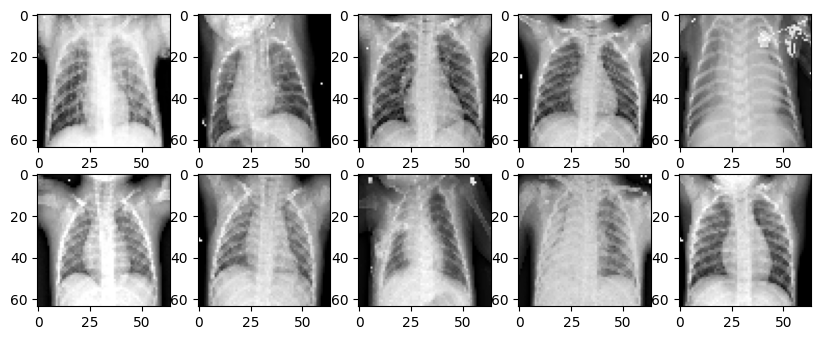

In [42]:
# Visualize first 10 images from train_ds
images, labels = next(iter(train_ds))
plt.figure(figsize=(10,10))
for i in range(10):
    ax = plt.subplot(5,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')


In [ ]:
cnn_model = create_cnn()
history, y_true, y_pred, results_df = train_and_evaluate(cnn_model, train_ds, val_ds, test_ds, test_description=test_description)
plot_results(history, y_true, y_pred)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 28s 278ms/step - accuracy: 0.5011 - loss: 0.7593 - precision: 0.5053 - recall: 0.4834 - val_accuracy: 0.5000 - val_loss: 0.7331 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.0000e-04
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 256ms/step - accuracy: 0.6008 - loss: 0.7177 - precision: 0.7712 - recall: 0.2612 - val_accuracy: 0.6250 - val_loss: 0.6602 - val_precision: 0.6667 - val_recall: 0.5000 - learning_rate: 3.0000e-04
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 257ms/step - accuracy: 0.8029 - loss: 0.5536 - precision: 0.8537 - recall: 0.7362 - val_accuracy: 0.6875 - val_loss: 0.7858 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 3.0000e-04
Epoch 4/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 21s 252ms/step - accuracy: 0.8228 - loss: 0.4433 - precision: 0.8385 - recall: 0.8096 - val_accuracy: 0.6875 - val_loss: 0.8898 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 3.0000e-04
Epoch 5/30
84/84 ━━━━━━━━━━━━━━━━━━━